# Chapter 5: Pre-training on Unlabeled Data

In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM. At the end of this chapter, we also load openly available pretrained weights from OpenAI into our model.

<img src="images/web01.png" width="800">

The topics covered in this chapter are shown below.

<img src="images/web02.png" width="600">

## 5.1 Evaluating Generative Text Models

We start this section with a brief recap of initializing a GPT model using the code from previous chapter. Then, we discuss basic evaluation metrics for LLMs. Lastly, in this section, we apply these evaluation metrics to a training and validation dataset.

### 5.1.1 Using GPT to Generate Text
We initialize a GPT model using the code from the previous chapter.


In [22]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays. Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key and value matrices, which is achieved by setting `qkv_bias: False`.

We reduce the context length of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens.
- This is so that more readers will be able to follow and execute the code examples on their laptop computer.
- However, please feel free to increase the `context_length` to 1024 tokens.

Next, we use the `generate_text_simple` function from the previous chapter to generate text. In addition, we define two convenience functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations that we use throughout this chapter. 
<img src="images/web03.png" width="600">

In [23]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # Add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # Remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


As we can see above, the model does not produce good text because it has not been trained yet.

How do we measure or capture what "good text" is, in a numeric form, to track it during training? The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress.

### 5.1.2 Calculating the Text Generation Loss: Cross-entropy and perplexity

Suppose we have an `inputs` tensor containing the token IDs for 2 training examples. Corresponding to the `inputs`, the `targets` contain the desired token IDs that we want the model to generate.
Notice that the `targets` are the `inputs` shifted by 1 position, as explained in chapter 2 when we implemented the data loader.

Feeding the `inputs` to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each. Each of the tokens is a 50257-dimensional vector corresponding to the size of the vocabulary.
Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores.

The figure below, using a very small vocabulary for illustration purposes, outlines how we convert the probability scores back into text, which we discussed at the end of the previous chapter.

<img src="images/web04.png" width="600">

As discussed in the previous chapter, we can apply the `argmax` function to convert the probability scores into predicted token IDs.
The softmax function above produced a 50257-dimensional vector for each token; the `argmax` function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.

Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs.

In [24]:
inputs = torch.tensor([[16833, 3626, 6100], # [ "every effort moves",
                       [40, 1107, 588]])    # "I really like"]

targets = torch.tensor([[3626, 6100, 345],  # [ "effort moves you",
                        [1107, 588, 11311]])# "really like chocolate"]

with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)  # Probability of each token in vocabulary
print(probas.shape)                     # Shape: (batch_size, num_tokens, vocab_size)

token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs: \n", token_ids)

print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")


torch.Size([2, 3, 50257])
Token IDs: 
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens.

That's because the model wasn't trained yet. To train the model, we need to know how far it is away from the correct predictions (targets).

<img src="images/web05.png" width="600">

The token probabilities corresponding to the target indices are as follows.

We want to maximize all these values, bringing them close to probability 1. In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself.

Next, we compute the average log probability.

In [25]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("Logarithm probabilities: ", log_probas)

# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print("Average probability: ",avg_log_probas)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])
Logarithm probabilities:  tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
Average probability:  tensor(-10.7940)


The goal is to make this average log probability as large as possible by optimizing the model weights. Due to the log, the largest possible value is 0, and we are currently far away from 0.

In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that is approaches to 0, we would minimize the 10.7722 so that it approaches 0. The value negative of -10.7722 is also called cross-entropy loss in deep learning.

PyTorch already implements a `cross_entropy` function that carries out the previous steps.

<img src="images/web06.png" width="600">

Before we apply the `cross_entropy` function, let's check the shape of the logits and targets.

For the `cross_entropy` function in PyTorch, we want to flatten these tensors by combining them over the batch dimension.

Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize.

The `cross_entropy` function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized.

A concept related to the cross-entropy loss is the perplexity of an LLM. The perplexity is simply the exponential of the cross-entropy loss.

In [26]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

# Logits have shape: (batch_size, num_tokens, vocab_size)
print("Logits shape: ", logits.shape)

# Targets have shape: (batch_size, num_tokens)
print("Targets shape: ", targets.shape)

logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flatten logits: ", logits_flat.shape)
print("Flatten targets: ", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("The cross entropy value: ", loss)

perplexity = torch.exp(loss)
print("The perplexity value: ", perplexity)

tensor(10.7940)
Logits shape:  torch.Size([2, 3, 50257])
Targets shape:  torch.Size([2, 3])
Flatten logits:  torch.Size([6, 50257])
Flatten targets:  torch.Size([6])
The cross entropy value:  tensor(10.7940)
The perplexity value:  tensor(48725.8203)


The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step. In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.

Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution.

### 5.1.3 Calculating the Training and Validation Set Losses

We use a relatively small dataset for training the LLM.

The reasons are:
- You can run the code examples in a few minutes on a laptop computer without a suitable GPU.
- The training finishes relatively fast, which is good for educational purpose.
- We use a text from the public domain, which can be included in this GitHub repo without violating any usage rights or bloating the repo size.

In [27]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

# First 99 characters
print(text_data[:99])

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters: ", total_characters)
print("Tokens: ", total_tokens)

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
Characters:  20479
Tokens:  5145


With 5145 tokens, the text is very short for training an LLM, but again, it's for educational purposes.

Next, we divide the dataset into a training and a validation set and use the data loaders from chap 02 to prepare the batches for LLM training.
For visualization purposes, the figure below assumes a `max_length=6`, but for the training loader, we set the `max_length` equal to the context length that the LLM supports.

The figure below only shows the input tokens for simplicity. Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position.

<img src="images/web07.png" width="600">

We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with.

Llama 27B trained with a batch size of 1024 for example.

In [28]:
from previous_chapters import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for training loader.")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader.")

train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens: ", train_tokens)
print("Validation tokens: ", val_tokens)
print("All tokens: ", train_tokens + val_tokens)

Training tokens:  4608
Validation tokens:  512
All tokens:  5120


Next, we implement a utility function to calculate the cross-entropy loss of a given batch.

In addition, we implement a second utility function to compute the loss for a user-specific number of batches in a data loader.

If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code. Via the `device` setting, we ensure that the data is loaded onto the same device as the LLM model.

<img src="images/web08.png" width="600">

In [29]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss/num_batches

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

model.to(device) # No assignment necessary for nn.Module classes 
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss: ", train_loss)
print("Validation loss: ", val_loss)

Using cpu device.
Training loss:  10.98758347829183
Validation loss:  10.981106758117676


## 5.2 Training an LLM

In this section, we finally implement the code for training the LLM. We focus on a simple training function.

<img src="images/web09.png" width="400">

Then, let's train the LLM using the training function defined.

In [30]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()       # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()       # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()             # Calculate loss gradients
            optimizer.step()            # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}):"
                        f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))
        model.train()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000):Train loss 9.783, Val loss 9.927
Ep 1 (Step 000005):Train loss 8.050, Val loss 8.333
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010):Train loss 6.758, Val loss 7.046
Ep 2 (Step 000015):Train loss 6.142, Val loss 6.630
Every effort moves you, and, and, and, and, and, and, and.                                   
Ep 3 (Step 000020):Train loss 13.925, Val loss 14.195
Ep 3 (Step 000025):Train loss 5.513, Val loss 6.420
Every effort moves you, and to the"                                             
Ep 4 (Step 000030):Train loss 5.165, Val loss 6.381
Ep 4 (Step 000035):Train loss 4.753, Val loss 6.316
Every effort moves you.                           "I"I"I"I it's"I"I"I"I"I"I
Ep 5 (Step 000040):Train loss 4.627, Val loss 6.394
Every effort moves you, I had been.                       "II me, and he had the donkey.           
Ep 6 (Step 000045):Train loss 4.026, Val loss 6.260
Ep 6 (Step 000050):Train loss 3.541, Val loss 6.210
Ev

Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar. Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions.

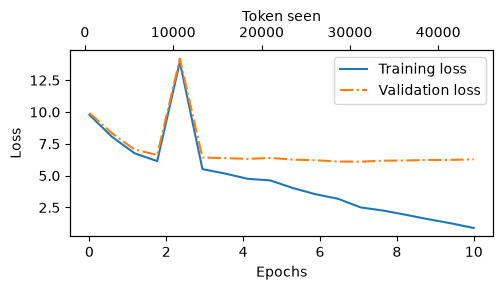

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Token seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Looking at the results above, we can see that the model starts out generating incomprehensible strings of words, whereas towards the end, it's able to produce grammatically more or less correct sentences. However, based on the training and validation set losses, we can see that the model starts overfitting.

If we were to check a few passages if writes towards the end, we would find that they are contained in the training set verbatim -- it simply memorize the training data. Later, we will cover decoding strategies that can mitigate this memorization by a certain degree.

<img src="images/web10.png" width="600">

## 5.3 Decoding Strategies to Control Randomness

Inference is relatively cheap with a relatively small LLM as the GPT model we trained above, so there's no need to use a GPU for it in case you used a GPU for training it above. Using `generate_text_simple` function that we used earlier inside the training function, we can generate new text one word at a time.

As explained in section 5.1.2, the next generated token is the token corresponding to the largest probability score among all tokens in the vocabulary.


In [32]:
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the picture for nothing--I told Mrs.
"Oh, my work, and went on grop


Even if we execute the `generate_text_simple` function above multiple times, the LLM will always generate the same outputs.

We now introduce two concepts, so-called decoding strategies, to modify the `generate_text_simple`: temperature scaling and top-k sampling. These will allow the model to control the randomness and diversity of the generated text.

### 5.3.1 Temperature Scaling

Previously, we always sampled the token with the highest probability as the next token using `torch.argmax`. To add variety, we can sample the next token using the `torch.multinomial(probas, num_samples=1)`, sampling from a probability distribution. Here, each index's chance of being picked corresponds to its probability in the input tensor.

Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution.

In [33]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# Returns the following logits for the next token.
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

forward
toward
71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


We can control the distribution and selection process via a concept called temperature scaling. "Temperature scaling" is just a fancy word for dividing the logits by a number greater than 0.

Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax. Temperatures smaller than 1 will result in more confident (sharper) distributions after applying the softmax.

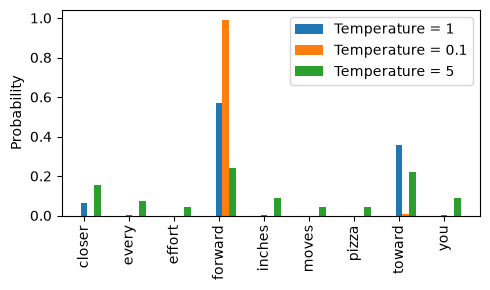

In [34]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature value
temperatures = [1, 0.1, 5]

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i*bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

### 5.3.2 Top-k Sampling

To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens.

<img src="images/web11.png" width="600">



In [35]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print("New logits:", new_logits)

top_k_probas = torch.softmax(new_logits, dim=0)
print("New probabilities:", top_k_probas)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
New logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
New probabilities: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 Modifying the Text Generation Function

The previous two subsections introduced temperature sampling and top-k sampling. Let's use these two concepts to modify the `generate_text_simple` function from chapter 4, creating a new `generate` function.

In [36]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probas, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generating early if end-of-sequence token is encountered
        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know began to happen a little wild--I was such a laugh; and his own existed."

" to see it


## 5.4 Loading and Saving Model Weights in PyTorch

Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights.

<img src="images/web12.png" width="600">

The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method.

Then we can load the model weights into a new `GPTModel` model instance as follows.

In [37]:
torch.save(model.state_dict(), "model.pth")
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device: ", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device:  cpu


It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD.

These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later.

In [38]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
},
    "model_and_optimizer.pth")

checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();